# Chapter 27: The Mathematics of Delegation

A controller reaches the edge of its authority and asks for review. That is often the correct action, but delegation does not make the remaining work disappear. A reviewer has finite service capacity, and a growing queue can consume the deadline before approval arrives.

This notebook combines an authority handoff predicate with a simple review queue. It identifies tasks that may proceed autonomously, tasks requiring a review packet, and tasks whose declared mean review time exceeds their deadline. The method keeps review receipt separate from human authority. Its output is a scheduling and authorization diagnostic, not a sent message or a prediction that a particular reviewer will answer on time.

**Outcome:** Compute a review queue diagnostic and identify required handoff packets and release blockers.

- Inspect the declared input contract
- Predict the hand-checkable case
- Run the shared computation
- Change the critical assumption
- Apply the method to the transfer data

**Guided route:** Run the worked calculation, inspect its figure, change the stated assumption, and try the transfer case. Read the explanations beside each result before opening the answers.

**Deeper route:** First read the mathematics and canonical equation reference. Audit the input contract, predict the changed result, then inspect the shared chapter implementation and solve the questions independently. Both routes use the same calculations and preserve the equations.

## Technical Requirements

Python 3.11 or later, the complete laboratory folder, and the notebook dependencies listed in `requirements-notebooks.txt` (the launcher's **Install notebook tools** choice installs them; see START-HERE). Standard-library chapter commands also support Python 3.10. No API key, model account or network call is used by this experiment.

Prior knowledge:

- Python lists and dictionaries
- The mapped chapter and its notation

## The question and its mathematics

Let total arrival rate be lambda and delegated fraction f. Effective review arrival is lambda_review=lambda f. Under an M/M/1 construction with service rate mu, the queue is stable when lambda_review<mu. Mean system time, including service, is W=1/(mu-lambda_review). At or above capacity no finite stationary mean exists, so the output remains unavailable.

A task requires delegation when the agent lacks authority or its declared risk exceeds the autonomous threshold. In this simplified contract, autonomous release requires current agent authority and acceptable risk. Delegated release requires human authority, a received review, and a mean-time diagnostic that does not exceed the task deadline.

The last predicate is deliberately a planning convention, not a pathwise guarantee. Queue mean W is not a measured duration for an individual task. A receipt may in reality arrive earlier or later. The returned flag identifies incompatibility between the declared capacity plan and deadline, and should not be mistaken for evidence that a specific observed review was late.

## Apply this to an agent

Sending a task to a human adds a capacity and authority boundary to the agent workflow. Inspect queue load, the review packet and the fallback when a receipt is missing. Mean review time diagnoses pressure; it does not guarantee an individual deadline.

## A calculation you can run

Supply arrival and service rates in the same time unit, delegated fraction, risk threshold, and task rows. Exact booleans distinguish current agent authority, human authority, and review receipt. Validation requires positive service rate, valid probabilities, and nonnegative deadlines.

The function calculates effective load, stability, and mean sojourn when available. It then emits delegation-required, queue-mean-exceeds-deadline, release, and review-packet-required flags for each task. The sensitivity figure varies review arrivals below service capacity and shows how mean time grows near saturation. In the changed case increase the delegated fraction while preserving total arrivals and service rate. Predict which releases the capacity contract will block.

The next cell finds the bundle and imports the same computation used by the chapter skill. It does not change your system Python.

In [1]:
from pathlib import Path
import sys, json
LAB_ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / "lab-manifest.json").is_file()), None)
if LAB_ROOT is None:
    raise RuntimeError("Open this notebook from the complete extracted laboratory folder.")
sys.path.insert(0, str(LAB_ROOT / "src"))
from math_ai_agents.core import analyze, report_text
from math_ai_agents.plotting import figure_svg
from IPython.display import SVG, display


Set the declared inputs below. These are constructed teaching values, not measurements from a production agent. Change a value only after predicting what it should change.

In [2]:
chapter = 27
inputs = {'arrival_rate': 4,
 'service_rate': 3,
 'delegation_fraction': 0.5,
 'agent_risk_limit': 0.1,
 'tasks': [{'name': 'routine',
            'agent_authorized': True,
            'risk': 0.02,
            'deadline': 2,
            'human_authorized': False,
            'review_received': False},
           {'name': 'release',
            'agent_authorized': False,
            'risk': 0.05,
            'deadline': 2,
            'human_authorized': True,
            'review_received': True},
           {'name': 'sensitive',
            'agent_authorized': False,
            'risk': 0.2,
            'deadline': 2,
            'human_authorized': True,
            'review_received': False}]}
report = analyze(chapter, inputs)
# This input was explicitly taken from the teaching fixture.
report['evidence_kind'] = 'constructed teaching example'
print(report_text(report))

Chapter 27: delegation-queue
Can human review supply missing authority within the workflow's capacity and timing contract?
Evidence: constructed teaching example

Calculated quantities:
{
  "effective_review_arrival_rate": 2.0,
  "queue_stable": true,
  "mean_review_sojourn": 1.0,
  "tasks": [
    {
      "task": "routine",
      "delegation_required": false,
      "queue_mean_exceeds_deadline": false,
      "released": true,
      "review_packet_required": false
    },
    {
      "task": "release",
      "delegation_required": true,
      "queue_mean_exceeds_deadline": false,
      "released": true,
      "review_packet_required": false
    },
    {
      "task": "sensitive",
      "delegation_required": true,
      "queue_mean_exceeds_deadline": false,
      "released": false,
      "review_packet_required": true
    }
  ],
  "released_count": 2
}

Interpretation:
Delegation moves work into a limited review service. Missing authority remains a release blocker even when expected revi

Default review load is 4(0.5)=2, below service rate 3. Mean sojourn is 1/(3-2)=1 time unit. Routine is authorized and below the agent risk limit, so it can proceed autonomously. Release requires delegation but has human authority and a received review, with deadline 2 exceeding the mean diagnostic, so it passes the declared release contract.

Sensitive lacks a received review and requires a packet. With delegated fraction 0.9, review load becomes 3.6, exceeding capacity. The stationary mean is unavailable and delegated release is blocked by the capacity plan. Routine remains autonomous. Review capacity did not change the underlying authority predicate.

The mean-versus-deadline flag is a planning diagnostic, not a probability of meeting the deadline. If the M/M/1 first-come-first-served assumption held exactly, sojourn time would be exponential with rate 3-2=1, so with deadline 2 the chance of meeting it would be 1-exp(-2), about 0.865, even though the mean 1 is below 2. This probability is a hand calculation, not a field the lab reports.

The plot below uses the calculated quantities. Read each panel's units before comparing its values.

Matplotlib is building the font cache; this may take a moment.


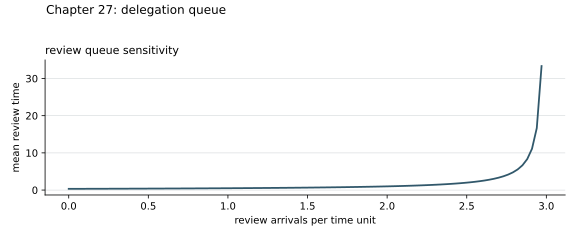

In [3]:
display(SVG(figure_svg(report)))

**Figure 27.L1:** Calculated chapter experiment. Each panel labels its input and output units; interpret it under the assumptions printed in the report.

## Change the assumption

Delegation can fail when it becomes an automatic escape from uncertainty without a capacity model. Sending every doubtful task to a fixed reviewer raises arrival load and can make the queue unstable. The sensitivity curve shows that even stable load near capacity creates large mean delays.

A queue calculation can also be overread. M/M/1 assumes Poisson arrivals, exponential service, one reviewer, and stationary rates. Real review teams may batch work, prioritize cases, or have correlated arrivals. A single mean cannot prove deadline compliance or determine an actual task's elapsed review time.

Authority remains independent. A review receipt from someone without the required permission cannot authorize release. Conversely, the method's mean-time flag is not evidence that an already received review was late. Preserve actual timestamps for empirical deadline checks and use this output as a capacity-design diagnostic.

Chapter 27: delegation-queue
Can human review supply missing authority within the workflow's capacity and timing contract?
Evidence: constructed changed-assumption example

Calculated quantities:
{
  "effective_review_arrival_rate": 3.6,
  "queue_stable": false,
  "mean_review_sojourn": null,
  "tasks": [
    {
      "task": "routine",
      "delegation_required": false,
      "queue_mean_exceeds_deadline": false,
      "released": true,
      "review_packet_required": false
    },
    {
      "task": "release",
      "delegation_required": true,
      "queue_mean_exceeds_deadline": true,
      "released": false,
      "review_packet_required": false
    },
    {
      "task": "sensitive",
      "delegation_required": true,
      "queue_mean_exceeds_deadline": true,
      "released": false,
      "review_packet_required": true
    }
  ],
  "released_count": 1
}

Interpretation:
Delegation moves work into a limited review service. Missing authority remains a release blocker even when ex

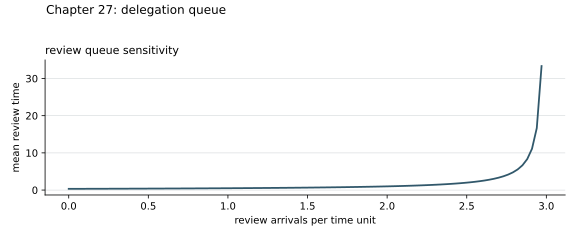

In [4]:
changed_inputs = {'arrival_rate': 4,
 'service_rate': 3,
 'delegation_fraction': 0.9,
 'agent_risk_limit': 0.1,
 'tasks': [{'name': 'routine',
            'agent_authorized': True,
            'risk': 0.02,
            'deadline': 2,
            'human_authorized': False,
            'review_received': False},
           {'name': 'release',
            'agent_authorized': False,
            'risk': 0.05,
            'deadline': 2,
            'human_authorized': True,
            'review_received': True},
           {'name': 'sensitive',
            'agent_authorized': False,
            'risk': 0.2,
            'deadline': 2,
            'human_authorized': True,
            'review_received': False}]}
changed = analyze(chapter, changed_inputs)
changed['evidence_kind'] = 'constructed changed-assumption example'
print(report_text(changed))
display(SVG(figure_svg(changed)))

**Figure 27.L2:** The changed-assumption result. Compare the printed quantities and the stated assumptions with the first run. A different input need not imply a causal effect in a deployed agent.

## Try a new case

The transfer review load is 1 with service rate 2, so mean sojourn is 1. The task deadline is 0.5, below that planning mean. Despite human authority and a declared receipt, the simplified capacity contract does not approve release. This flags the planning mismatch rather than asserting the actual receipt arrived after 0.5.

As a next step, draft a handoff packet containing current state, missing authority, risk, observations, proposed action, and deadline. Do not send it automatically from this computation. Measure real arrival and service patterns before adopting the queue law, and preserve review timestamps when evaluating individual deadline outcomes.

In [5]:
transfer_inputs = {'arrival_rate': 1,
 'service_rate': 2,
 'delegation_fraction': 1,
 'agent_risk_limit': 0.05,
 'tasks': [{'name': 'approval',
            'agent_authorized': False,
            'risk': 0.01,
            'deadline': 0.5,
            'human_authorized': True,
            'review_received': True}]}
transfer = analyze(chapter, transfer_inputs)
transfer['evidence_kind'] = 'constructed transfer example'
print(report_text(transfer))

Chapter 27: delegation-queue
Can human review supply missing authority within the workflow's capacity and timing contract?
Evidence: constructed transfer example

Calculated quantities:
{
  "effective_review_arrival_rate": 1.0,
  "queue_stable": true,
  "mean_review_sojourn": 1.0,
  "tasks": [
    {
      "task": "approval",
      "delegation_required": true,
      "queue_mean_exceeds_deadline": true,
      "released": false,
      "review_packet_required": false
    }
  ],
  "released_count": 0
}

Interpretation:
Delegation moves work into a limited review service. Missing authority remains a release blocker even when expected review capacity is adequate.

Assumptions:
- M/M/1 review queue with Poisson arrivals, exponential service, one reviewer.
- Arrival and service rates use the same time unit.
- Deadline test uses mean queue sojourn as a diagnostic, not a per-task prediction.

Limitations:
- A queue mean does not prove any individual deadline will be met.
- A human review receipt 

## Apply the method to your inputs

The example file below has the exact input shape the method accepts. Copy it to a new file, replace its values, then point `reader_file` at your copy. Run the cell again. Supplied inputs retain their stated provenance; the program cannot establish that they are representative observations.

- **arrival_rate:** Nonnegative incoming task rate per declared time unit.
- **service_rate:** Positive reviewer service rate in the same unit.
- **delegation_fraction:** Fraction in [0,1] entering review.
- **agent_risk_limit:** Probability threshold in [0,1] for autonomous task handling.
- **tasks:** Rows with name,agent_authorized:boolean,risk:probability,deadline:nonnegative time,human_authorized:boolean,review_received:boolean.

In [6]:
reader_file = LAB_ROOT / 'data/examples/ch27.json'
reader_inputs = json.loads(reader_file.read_text())
reader_report = analyze(chapter, reader_inputs)
print(report_text(reader_report))

Chapter 27: delegation-queue
Can human review supply missing authority within the workflow's capacity and timing contract?
Evidence: supplied local inputs; provenance not independently verified

Calculated quantities:
{
  "effective_review_arrival_rate": 1.0,
  "queue_stable": true,
  "mean_review_sojourn": 1.0,
  "tasks": [
    {
      "task": "approval",
      "delegation_required": true,
      "queue_mean_exceeds_deadline": true,
      "released": false,
      "review_packet_required": false
    }
  ],
  "released_count": 0
}

Interpretation:
Delegation moves work into a limited review service. Missing authority remains a release blocker even when expected review capacity is adequate.

Assumptions:
- M/M/1 review queue with Poisson arrivals, exponential service, one reviewer.
- Arrival and service rates use the same time unit.
- Deadline test uses mean queue sojourn as a diagnostic, not a per-task prediction.

Limitations:
- A queue mean does not prove any individual deadline will b

## Explore the four chapter demonstrations

The following sections reproduce every demonstration in the illustrated chapter reader. They use the same declared controls, calculation and figure. Begin with the prediction, run the worked case, change one control, then inspect the complete state table. The chapter experiment above remains available for your own compatible inputs.

In [7]:
from math_ai_agents.demos import demo_catalog, demo_states, run_demo, demo_report_text

<a id="demo-c27-d01"></a>

### Demonstration 1: Defer by comparing correctness, then price the deadline

If the model is 0.78 sure, when should the case go to an expert instead, and does the expert's accuracy alone settle it once the answer has to arrive in time?

![Equation 27.2](../assets/math/7975917fee2d7cc96458.svg)

**Symbols and units:** x is the case. The classifier's best class has probability max_y p(y | x) of being correct. p_E(x) is the probability that the designated expert E is correct on this case. Del(E, Delta) means delegate to E with maximum wait Delta. The arg max picks the most probable class. For the value comparison, a correct result is worth 10 and a wrong one -10, delegating costs a fee of 1 whether or not a reply arrives, and t is the probability the reply comes on time; a missed deadline triggers an authorized fallback worth 2. Probabilities are between 0 and 1.

Equation (27.2) compares two chances of being correct and sends the case to whichever side is higher, with ties going to the expert. The model's confidence only matters as one of the two numbers. It also treats the delay as costless. Once the reply can miss its deadline, delegation's value mixes the timely branch and the fallback and pays the fee on both, so the expert's conditional accuracy cannot answer the question alone; the break-even on-time probability is where the two values meet.

**Use in this chapter:** A single confidence threshold such as 0.80, below which everything is sent to review, is justified only if the destination's correctness and timeliness are the same for all the cases it covers. Otherwise ask how likely the actual destination is to be right on this kind of case, how likely it is to answer in time, and compare with acting.

**Assumptions:** Zero-one loss for Equation (27.2), one expert, and a known expert probability for this case type. The classifier's confidence is assumed calibrated. The utilities, fee and fallback value come from the workbench's constructed problem and are applied here to all four cases for comparison. The expert's accuracy is conditional on a timely reply and is not a permanent rating; if the probability is only a rough average, or the packet omits the evidence the expert needs, the comparison is no better than its inputs.

**Predict before running:** Pick the workbench case (acting is right 0.80, expert 0.95). With a guaranteed on-time return delegation wins 8 against 6. Now set the on-time probability to 0.60. Which route wins?

**Controls you can change:**

- **Case:** `case` accepts 'chapter', 'general', 'bench', 'tie'.
- **Probability the reply arrives on time (t):** `timely` accepts 1.0, 0.6, 0.7142857142857143.

**Source section:** A value comparison, not a confidence threshold.

**Evidence:** constructed teaching example.

Constructed example: the chapter's two cases (model 0.78, expert 0.95 or 0.60) and the workbench's timely-return problem (acting 0.80, utilities 10 and -10, fee 1, fallback 2).

Prediction choices:

1. Delegation still wins
2. Acting wins
3. They tie

**Boundary of the conclusion:** The chapter does not show how to estimate every action value, reviewer-error rate, queue delay, observation value, or authority boundary in a live institution.

**Common wrong turn:** The chapter calls this an intuitive but mistaken rule. Uncertainty is only one side of a comparison: an uncertain model may still be better than the available destination, and a confident model may be worse than a destination with decisive side information.

Defer by comparing correctness, then price the deadline
Controls: {"case": "chapter", "timely": 1.0}
Evidence: constructed teaching example

Calculated quantities:
Classifier best class probability: 0.78
Expert correctness p_E: 0.95
Route by Equation (27.2), delay ignored: Delegate to E
Value of acting now: 5.60
Value of delegating: 8.00
Route with the higher value: delegate
Timely-return probability that ties them: 0.657

Worked steps:
1. Equation (27.2): 0.95 >= 0.78, so it delegates (gap 0.95 - 0.78 = 0.17).
2. Act = 0.78 x 10 + 0.22 x (-10) = 5.60.
3. Timely review gross = 0.95 x 10 + 0.05 x (-10) = 9.00.
4. Delegate = 1.00 x 9.00 + 0.00 x 2 - 1 = 8.00; the fee is paid on both branches.
5. Higher value: delegate (5.60 against 8.00).

Equation (27.2): 0.95 >= 0.78, so it delegates (gap 0.95 - 0.78 = 0.17). Act = 0.78 x 10 + 0.22 x (-10) = 5.60. Delegate = t x gross + (1 - t) x 2 - 1 = 1.00 x 9.00 + 0.00 x 2 - 1 = 8.00, where gross = 0.95 x 10 + 0.05 x (-10) = 9.00. The two readings 

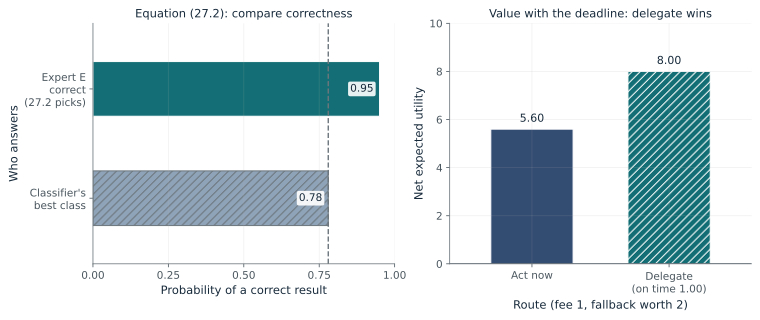

In [8]:
demo_id = 'C27-D01'
demo_controls = {'case': 'chapter', 'timely': 1.0}
demo_result = run_demo(27, demo_id, demo_controls)
print(demo_report_text(demo_result))
display(SVG(demo_result['figure_svg']))

Change only **Case** below. Predict which quantity and part of the figure should change. Keep the other inputs fixed so the comparison has a clear meaning.

Defer by comparing correctness, then price the deadline
Controls: {"case": "general", "timely": 1.0}
Evidence: constructed teaching example

Calculated quantities:
Classifier best class probability: 0.78
Expert correctness p_E: 0.60
Route by Equation (27.2), delay ignored: Predict the most probable class
Value of acting now: 5.60
Value of delegating: 1.00
Route with the higher value: act now
Timely-return probability that ties them: none (delegation never matches acting)

Worked steps:
1. Equation (27.2): 0.60 < 0.78, so it keeps the prediction; confidence 0.78 alone is not a reason to delegate.
2. Act = 0.78 x 10 + 0.22 x (-10) = 5.60.
3. Timely review gross = 0.60 x 10 + 0.40 x (-10) = 2.00.
4. Delegate = 1.00 x 2.00 + 0.00 x 2 - 1 = 1.00; the fee is paid on both branches.
5. Higher value: act now (5.60 against 1.00).

Equation (27.2): 0.60 < 0.78, so it keeps the prediction; confidence 0.78 alone is not a reason to delegate. Act = 0.78 x 10 + 0.22 x (-10) = 5.60. Delegate = t x gros

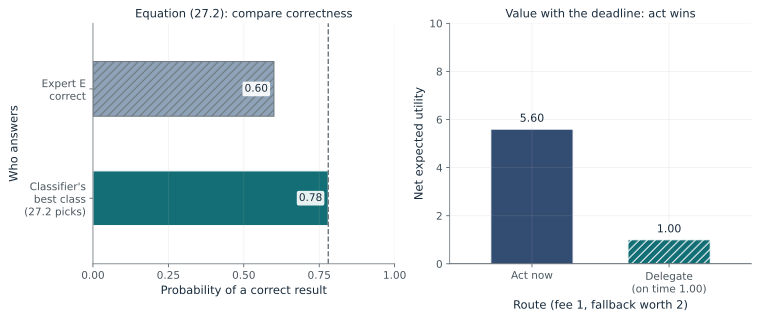

In [9]:
changed_controls = {'case': 'general', 'timely': 1.0}
changed_demo = run_demo(27, 'C27-D01', changed_controls)
print(demo_report_text(changed_demo))
display(SVG(changed_demo['figure_svg']))

The complete table below reruns every selectable state in the web demonstration. Each row contains the controls and calculated quantities. It establishes coverage; the separate analytical tests check whether those quantities are mathematically correct.

In [10]:
state_rows = []
for controls in demo_states(27, 'C27-D01'):
    state = run_demo(27, 'C27-D01', controls, include_figure=False)
    state_rows.append({'controls': controls, 'metrics': state['metrics']})
print(json.dumps(state_rows, indent=2, ensure_ascii=False))

[
  {
    "controls": {
      "case": "chapter",
      "timely": 1.0
    },
    "metrics": [
      [
        "Classifier best class probability",
        "0.78"
      ],
      [
        "Expert correctness p_E",
        "0.95"
      ],
      [
        "Route by Equation (27.2), delay ignored",
        "Delegate to E"
      ],
      [
        "Value of acting now",
        "5.60"
      ],
      [
        "Value of delegating",
        "8.00"
      ],
      [
        "Route with the higher value",
        "delegate"
      ],
      [
        "Timely-return probability that ties them",
        "0.657"
      ]
    ]
  },
  {
    "controls": {
      "case": "chapter",
      "timely": 0.6
    },
    "metrics": [
      [
        "Classifier best class probability",
        "0.78"
      ],
      [
        "Expert correctness p_E",
        "0.95"
      ],
      [
        "Route by Equation (27.2), delay ignored",
        "Delegate to E"
      ],
      [
        "Value of acting now",
        "5.

**Check your understanding:** A model is 0.97 sure and an expert is right with probability 0.95. Which route does Equation (27.2) choose, and by how much?

[Answer and worked reasoning](../solutions/ch27.md#demonstration-1). [Matching browser demonstration](../readers/27-delegation-queue/reader.html#C27-D01).

<a id="demo-c27-d02"></a>

### Demonstration 2: Four routes, but only the authorized ones can run

Which routes are in the authorized set, which of them has the highest net value, and what removes a route?

![Equation 27.1](../assets/math/de77306687ec0648e0c4.svg)

![Equation 27.3](../assets/math/b6ceb29c5e478c1354a4.svg)

**Symbols and units:** A route is one choice such as release now, review, wait or hold. The four rows are the chapter's act (release now), delegate (review), wait and narrow (the reversible hold); returning control is not given a value here. A_auth(x) is the set of actions in state x with Authorized = 1 (a declared grant covers them) and Pre = 1 (their state-specific preconditions hold, here a reviewer being available). R_auth(x) is the set of authorized routes, and V(route, x) is the route's net value in constructed utility units. Fraud has probability 0.10. A hold makes timely review likely (0.95) and costs the amount you choose; the timeout branch is worth -4. Review itself costs 1.

Equation (27.1) first filters the actions: a route is available only if it is authorized and its preconditions hold. Equation (27.3) then takes the highest-value route among those. Timely review has gross value 8.04, and the hold turns that into 0.95 x 8.04 + 0.05 x (-4) - 1 minus its own cost, so its value falls one point for each point of hold cost. An excluded route is not low-scoring, it is absent: if it would have won, it stays a recommendation.

**Use in this chapter:** Write the table for a consequential action: one row per route, each with its payoff, delay cost and fallback, and next to each row the grant that authorizes it and the precondition it needs. Then keep only the rows that are actually permitted. A delegation row also needs a named destination, a deadline and a fallback; without them it is not a route.

**Assumptions:** Utilities, fraud probability, review error rates (detect fraud 0.94, wrongly reject 0.02) and response probabilities are the chapter's constructed values, and all four routes are costed on one scale. Real stakes may not fit one scale; a hard boundary may belong in the authorized set rather than in a cost. Changing any stated probability can change the winner. The reviewer accuracy here is held fixed, although in practice it can change with workload.

**Predict before running:** The hold costs 2 by default and wins. Raise its cost to 5 with every route authorized. Which route has the highest value?

**Controls you can change:**

- **Cost of the reversible hold:** `hold_cost` accepts 2, 4, 5.
- **Authority and preconditions:** `status` accepts 'all', 'holdno', 'unavail', 'stopped'.

**Source section:** Queue economics: what timely review is worth.

**Evidence:** constructed teaching example.

Constructed example: the book's own route-value table for the pending transfer (values -1, 1.164, 2 and 4.438), with the hold cost and the authority status varied.

Prediction choices:

1. The hold
2. Waiting for confirmation
3. Review with release on timeout
4. Release now

**Boundary of the conclusion:** The chapter does not make human review an oracle, nor does it rank every refusal above every act. Its bounded conclusion is structural: delegation requires a named route and must compete with acting, waiting, narrowing and returning control.

**Common wrong turn:** The chapter says a high-scoring action absent from the authorized set remains a recommendation, not an executable act, and that the system can recommend an excluded action but cannot execute it merely because it ranked highly. Reversibility is not free either: a hold has its own cost.

Four routes, but only the authorized ones can run
Controls: {"hold_cost": 2, "status": "all"}
Evidence: constructed teaching example

Calculated quantities:
Release now: -1.000
Review; release on timeout: 1.164
Wait for confirmation; release on timeout: 2.000
Reversible hold and review; return on timeout: 4.438
Routes in the authorized set: release now, review, wait for confirmation, reversible hold and review
Highest among the authorized routes: Reversible hold and review; return on timeout
Hold cost at which waiting (2) overtakes it: 4.438

Worked steps:
1. Timely review gross = 8.64 + (-0.60) = 8.04.
2. Net values: release -1.000, review 1.164, wait 2.000, hold 4.438.
3. Hold = 0.95 x 8.04 + 0.05 x (-4) - 2 - 1 = 4.438.
4. Status: All four routes authorized and the reviewer is available.
5. Authorized set: release now, review, wait for confirmation, reversible hold and review.
6. Highest value inside the set: Reversible hold and review; return on timeout at 4.438.

Hold = 0.95 x 8.0

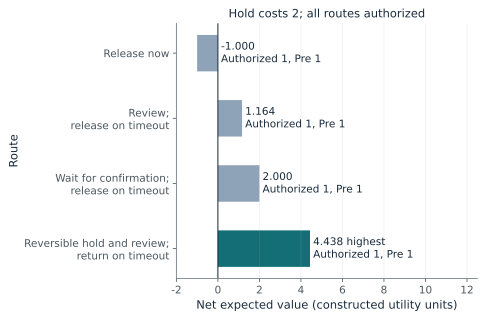

In [11]:
demo_id = 'C27-D02'
demo_controls = {'hold_cost': 2, 'status': 'all'}
demo_result = run_demo(27, demo_id, demo_controls)
print(demo_report_text(demo_result))
display(SVG(demo_result['figure_svg']))

Change only **Cost of the reversible hold** below. Predict which quantity and part of the figure should change. Keep the other inputs fixed so the comparison has a clear meaning.

Four routes, but only the authorized ones can run
Controls: {"hold_cost": 4, "status": "all"}
Evidence: constructed teaching example

Calculated quantities:
Release now: -1.000
Review; release on timeout: 1.164
Wait for confirmation; release on timeout: 2.000
Reversible hold and review; return on timeout: 2.438
Routes in the authorized set: release now, review, wait for confirmation, reversible hold and review
Highest among the authorized routes: Reversible hold and review; return on timeout
Hold cost at which waiting (2) overtakes it: 4.438

Worked steps:
1. Timely review gross = 8.64 + (-0.60) = 8.04.
2. Net values: release -1.000, review 1.164, wait 2.000, hold 2.438.
3. Hold = 0.95 x 8.04 + 0.05 x (-4) - 4 - 1 = 2.438.
4. Status: All four routes authorized and the reviewer is available.
5. Authorized set: release now, review, wait for confirmation, reversible hold and review.
6. Highest value inside the set: Reversible hold and review; return on timeout at 2.438.

Hold = 0.95 x 8.0

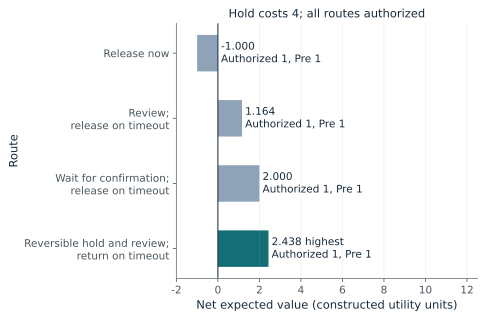

In [12]:
changed_controls = {'hold_cost': 4, 'status': 'all'}
changed_demo = run_demo(27, 'C27-D02', changed_controls)
print(demo_report_text(changed_demo))
display(SVG(changed_demo['figure_svg']))

The complete table below reruns every selectable state in the web demonstration. Each row contains the controls and calculated quantities. It establishes coverage; the separate analytical tests check whether those quantities are mathematically correct.

In [13]:
state_rows = []
for controls in demo_states(27, 'C27-D02'):
    state = run_demo(27, 'C27-D02', controls, include_figure=False)
    state_rows.append({'controls': controls, 'metrics': state['metrics']})
print(json.dumps(state_rows, indent=2, ensure_ascii=False))

[
  {
    "controls": {
      "hold_cost": 2,
      "status": "all"
    },
    "metrics": [
      [
        "Release now",
        "-1.000"
      ],
      [
        "Review; release on timeout",
        "1.164"
      ],
      [
        "Wait for confirmation; release on timeout",
        "2.000"
      ],
      [
        "Reversible hold and review; return on timeout",
        "4.438"
      ],
      [
        "Routes in the authorized set",
        "release now, review, wait for confirmation, reversible hold and review"
      ],
      [
        "Highest among the authorized routes",
        "Reversible hold and review; return on timeout"
      ],
      [
        "Hold cost at which waiting (2) overtakes it",
        "4.438"
      ]
    ]
  },
  {
    "controls": {
      "hold_cost": 2,
      "status": "holdno"
    },
    "metrics": [
      [
        "Release now",
        "-1.000"
      ],
      [
        "Review; release on timeout",
        "1.164"
      ],
      [
        "Wait for c

**Check your understanding:** If the hold cost 4 instead of 2, what is its net value and does it still beat waiting?

[Answer and worked reasoning](../solutions/ch27.md#demonstration-2). [Matching browser demonstration](../readers/27-delegation-queue/reader.html#C27-D02).

<a id="demo-c27-d03"></a>

### Demonstration 3: Delegating more can make review slower than the deadline

How does sending a larger share of tasks to one reviewer change the mean time in review, and which tasks can then be released?

![Mathematical relation](../assets/demo-equations/bd1e5589ebee1a72b2a3.svg)

**Symbols and units:** lambda is the arrival rate of tasks per hour. f is the delegation fraction, the share sent to review, so the reviewer sees f x lambda per hour. mu is the number of reviews the reviewer finishes per hour. The result is the mean hours a case spends waiting plus being reviewed. A stationary mean is that long-run average. In the ledger a task needs review when the agent is not authorized or its risk is above the agent's risk limit; it is released only with human authority, a received review packet and a mean time inside its deadline.

For one reviewer in the M/M/1 model, with random (Poisson) arrivals and exponentially distributed service times, the mean time in the system is 1/(mu - f x lambda) as long as the review arrivals stay below capacity. The time grows slowly at first and then steeply as the load approaches mu. At or beyond mu no stationary (long-run) mean exists and the backlog grows. The ledger shows what that does to the release contract: authority and a review packet are separate requirements from timing.

**Use in this chapter:** Before promising a review deadline, compare the planned review load with the reviewer's capacity. A rule such as delegate everything doubtful can overload the one route that was supposed to supply safety. Keep a route ledger per destination, with case type, deadline, packet completeness, response state and final action, so a failure can be placed: a bad recommendation, a wrong destination, a late answer or an unowned escalation.

**Assumptions:** The M/M/1 model: one reviewer, independent random (Poisson) arrivals at a steady rate, exponentially distributed service times with a steady rate, and a long-run mean. Other service-time shapes give a different formula. Batching, priorities, correlated arrivals or a changing reviewer break the model. A mean does not promise that any single case meets its deadline, and the laboratory's deadline test is a planning diagnostic, not a probability. The faster reviewer is defined for this reader.

**Predict before running:** With the default case (reviewer finishes 3 per hour), what happens to the mean time as the delegated share goes from 0.5 to 0.7? And at 0.9?

**Controls you can change:**

- **Case:** `case` accepts 'default', 'fast', 'transfer'.
- **Delegation fraction (f):** `delegation_fraction` accepts 0.5, 0.7, 0.9, 1.0.

**Source section:** Queue economics: what timely review is worth.

**Evidence:** constructed teaching example.

Constructed example: the notebook's default, changed and transfer cases and the chapter's queue example (4 tasks per hour, a reviewer finishing 3 per hour), computed with the laboratory's review-queue function, plus one faster reviewer defined for the reader.

Prediction choices:

1. 1 hour, then 5 hours, then no stationary mean
2. 1 hour, then 1.4 hours, then 2 hours
3. 1 hour at every share below 1

**Common wrong turn:** The chapter says a mean does not promise that any one case meets its deadline, and the notebook's output is a planning diagnostic. Individual timing needs observed timestamps; the queue formula is a capacity-design check.

Delegating more can make review slower than the deadline
Controls: {"case": "default", "delegation_fraction": 0.5}
Evidence: constructed teaching example

Calculated quantities:
Review arrivals f x lambda (per hour): 2.00
Reviewer capacity mu (per hour): 3
Mean time in system: 1.00 hours (60 minutes)
Tasks released: 2 of 3
Task outcomes: routine: autonomous; release: released after review; sensitive: blocked (no review packet)
Chance a delegated case meets the task deadline (M/M/1): 0.865

Worked steps:
1. Review arrivals = f x lambda = 0.50 x 4 = 2.00 per hour; capacity mu = 3.
2. Stable, since 2.00 < 3: mean = 1 / (3 - 2.00) = 1.00 hours.
3. Tasks above the agent risk limit 0.10 or without agent authority need review: release, sensitive.
4. A delegated task is released only with human authority, a received review packet and a mean inside its deadline.
5. Result: 2 of 3 tasks released.

Review arrivals = 0.50 x 4 = 2.00 per hour, below 3. Mean time in system = 1 / (3 - 2.00) = 1 / 1.0

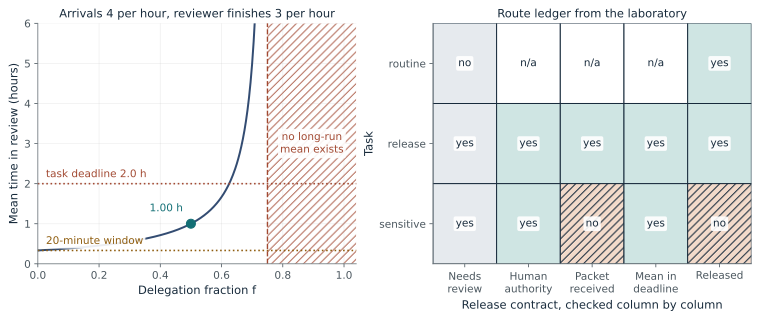

In [14]:
demo_id = 'C27-D03'
demo_controls = {'case': 'default', 'delegation_fraction': 0.5}
demo_result = run_demo(27, demo_id, demo_controls)
print(demo_report_text(demo_result))
display(SVG(demo_result['figure_svg']))

Change only **Case** below. Predict which quantity and part of the figure should change. Keep the other inputs fixed so the comparison has a clear meaning.

Delegating more can make review slower than the deadline
Controls: {"case": "fast", "delegation_fraction": 0.5}
Evidence: constructed teaching example

Calculated quantities:
Review arrivals f x lambda (per hour): 2.00
Reviewer capacity mu (per hour): 4
Mean time in system: 0.50 hours (30 minutes)
Tasks released: 2 of 3
Task outcomes: routine: autonomous; release: released after review; sensitive: blocked (no review packet)
Chance a delegated case meets the task deadline (M/M/1): 0.982

Worked steps:
1. Review arrivals = f x lambda = 0.50 x 4 = 2.00 per hour; capacity mu = 4.
2. Stable, since 2.00 < 4: mean = 1 / (4 - 2.00) = 0.50 hours.
3. Tasks above the agent risk limit 0.10 or without agent authority need review: release, sensitive.
4. A delegated task is released only with human authority, a received review packet and a mean inside its deadline.
5. Result: 2 of 3 tasks released.

Review arrivals = 0.50 x 4 = 2.00 per hour, below 4. Mean time in system = 1 / (4 - 2.00) = 1 / 2.00 =

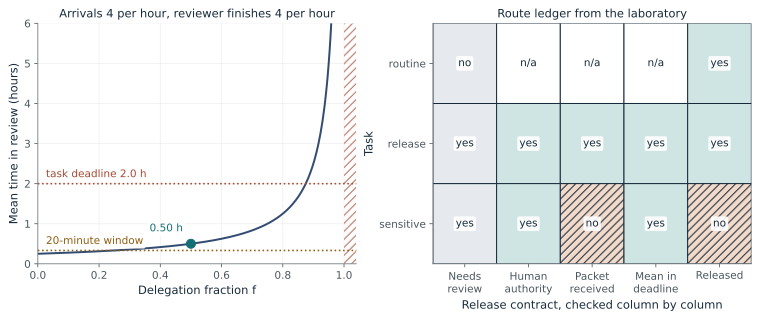

In [15]:
changed_controls = {'case': 'fast', 'delegation_fraction': 0.5}
changed_demo = run_demo(27, 'C27-D03', changed_controls)
print(demo_report_text(changed_demo))
display(SVG(changed_demo['figure_svg']))

The complete table below reruns every selectable state in the web demonstration. Each row contains the controls and calculated quantities. It establishes coverage; the separate analytical tests check whether those quantities are mathematically correct.

In [16]:
state_rows = []
for controls in demo_states(27, 'C27-D03'):
    state = run_demo(27, 'C27-D03', controls, include_figure=False)
    state_rows.append({'controls': controls, 'metrics': state['metrics']})
print(json.dumps(state_rows, indent=2, ensure_ascii=False))

[
  {
    "controls": {
      "case": "default",
      "delegation_fraction": 0.5
    },
    "metrics": [
      [
        "Review arrivals f x lambda (per hour)",
        "2.00"
      ],
      [
        "Reviewer capacity mu (per hour)",
        "3"
      ],
      [
        "Mean time in system",
        "1.00 hours (60 minutes)"
      ],
      [
        "Tasks released",
        "2 of 3"
      ],
      [
        "Task outcomes",
        "routine: autonomous; release: released after review; sensitive: blocked (no review packet)"
      ],
      [
        "Chance a delegated case meets the task deadline (M/M/1)",
        "0.865"
      ]
    ]
  },
  {
    "controls": {
      "case": "default",
      "delegation_fraction": 0.7
    },
    "metrics": [
      [
        "Review arrivals f x lambda (per hour)",
        "2.80"
      ],
      [
        "Reviewer capacity mu (per hour)",
        "3"
      ],
      [
        "Mean time in system",
        "5.00 hours (300 minutes)"
      ],
      

**Check your understanding:** With mu = 4 per hour and f = 0.75, what is the mean time in review in minutes?

[Answer and worked reasoning](../solutions/ch27.md#demonstration-3). [Matching browser demonstration](../readers/27-delegation-queue/reader.html#C27-D03).

<a id="demo-c27-d04"></a>

### Demonstration 4: Waiting needs an observation worth its delay and a fallback everywhere

When is it right to wait for a confirmation instead of acting now, and what if one state reachable by the deadline has no authorized fallback?

![Equation 27.4](../assets/math/f09c52733cdad330374e.svg)

**Symbols and units:** VOI(o) is the value of the observation o: here the extra expected value of waiting for the signed confirmation compared with releasing now. DelayCost is what the wait costs (2 units). q is the probability that the confirmation arrives in time. The fallback is what the controller does at the deadline, and it must be an authorized action in every state reachable by then: the observation arrives in time, arrives late, the case changes, or the source fails.

If the confirmation arrives, the transfer is handled correctly for a value of 9; if not, the fallback releases it at -1. So the gain over releasing now is 10 x q, a straight line. Equation (27.4) allows waiting only when that gain is strictly above the delay cost and the fallback is permitted in every reachable deadline state. One state without a permitted fallback is enough to fail the test, however valuable the observation.

**Use in this chapter:** When an agent says it will wait, ask four things: which fact would change the action, who supplies it, by when, and what happens if it never comes. If any answer is missing, there is no waiting action, only delay. If the observation source has become unavailable, move to the declared fallback instead of waiting under a plan that assumes its arrival.

**Assumptions:** One observation and the chapter's constructed values (9, -1, delay cost 2). VOI is read here as the gain over releasing now, a simple special case of the Chapter 8 idea. The four reachable states are the ones the chapter lists; a real case can have more. Equation (27.4) is a necessary test: passing it does not make waiting the best route.

**Predict before running:** At q = 0.20, with a fallback authorized in every state, does the test allow waiting?

**Controls you can change:**

- **Probability the confirmation arrives in time (q):** `arrival_probability` accepts 0.2, 0.5, 0.8.
- **State with no authorized fallback:** `gap` accepts 'none', 'late', 'changed', 'failed'.

**Source section:** Waiting is not hiding.

**Evidence:** constructed teaching example.

Constructed example: the chapter's wait route (value 9 on arrival, -1 at the fallback, delay cost 2) with the arrival probability and the missing-fallback state varied.

Prediction choices:

1. Yes, VOI equals the delay cost
2. No, the test needs VOI strictly above the delay cost
3. Yes, 0.20 is above zero

**Boundary of the conclusion:** The chapter does not prove that a learned rejector yields fair, lawful, safe, or corrigible deployment, and it does not show how to estimate every observation value or authority boundary in a live institution.

**Common wrong turn:** The chapter says waiting with no identified observation, no deadline and no fallback is not an information action; it is delay without a model. An agent that cannot say what missing fact would change the action, who supplies it, by when and what happens otherwise has named uncertainty without resolving authority.

Waiting needs an observation worth its delay and a fallback everywhere
Controls: {"arrival_probability": 0.5, "gap": "none"}
Evidence: constructed teaching example

Calculated quantities:
Value of information (VOI): 5.00
Delay cost: 2.00
VOI minus delay cost: 3.00
Fallback authorized in every reachable state: yes
Passes Equation (27.4): Yes (waiting allowed)
Break-even arrival probability: 0.20

Worked steps:
1. Gain from waiting over releasing now: VOI = 0.5 x 9 + 0.5 x (-1) - (-1) = 5.00.
2. Condition 1: VOI 5.00 against delay cost 2, needing strictly more: holds.
3. Reachable states by the deadline: in time, late, the case changes, the source fails.
4. Condition 2: the fallback must be authorized in every one: all four are.
5. Result: Yes (waiting allowed).

VOI = 0.5 x 9 + 0.5 x (-1) - (-1) = 5.00, and VOI - delay cost = 5.00 - 2 = 3.00. Both conditions hold: the observation is worth more than the delay and a fallback is permitted in all four reachable states, so waiting passes. Th

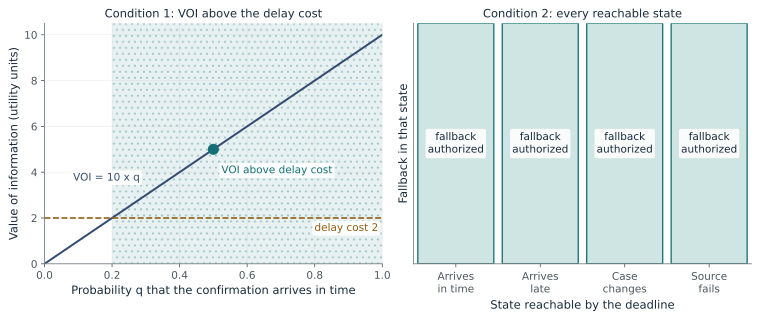

In [17]:
demo_id = 'C27-D04'
demo_controls = {'arrival_probability': 0.5, 'gap': 'none'}
demo_result = run_demo(27, demo_id, demo_controls)
print(demo_report_text(demo_result))
display(SVG(demo_result['figure_svg']))

Change only **Probability the confirmation arrives in time (q)** below. Predict which quantity and part of the figure should change. Keep the other inputs fixed so the comparison has a clear meaning.

Waiting needs an observation worth its delay and a fallback everywhere
Controls: {"arrival_probability": 0.2, "gap": "none"}
Evidence: constructed teaching example

Calculated quantities:
Value of information (VOI): 2.00
Delay cost: 2.00
VOI minus delay cost: 0.00
Fallback authorized in every reachable state: yes
Passes Equation (27.4): No (VOI equals delay cost)
Break-even arrival probability: 0.20

Worked steps:
1. Gain from waiting over releasing now: VOI = 0.2 x 9 + 0.8 x (-1) - (-1) = 2.00.
2. Condition 1: VOI 2.00 against delay cost 2, needing strictly more: fails.
3. Reachable states by the deadline: in time, late, the case changes, the source fails.
4. Condition 2: the fallback must be authorized in every one: all four are.
5. Result: No (VOI equals delay cost).

VOI = 0.2 x 9 + 0.8 x (-1) - (-1) = 2.00, and VOI - delay cost = 2.00 - 2 = 0.00. VOI equals the delay cost exactly. Equation (27.4) uses a strict inequality, so this is a boundary case and waiting is not allowed by th

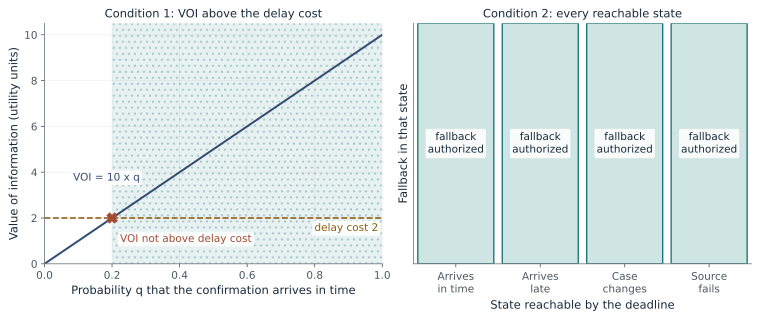

In [18]:
changed_controls = {'arrival_probability': 0.2, 'gap': 'none'}
changed_demo = run_demo(27, 'C27-D04', changed_controls)
print(demo_report_text(changed_demo))
display(SVG(changed_demo['figure_svg']))

The complete table below reruns every selectable state in the web demonstration. Each row contains the controls and calculated quantities. It establishes coverage; the separate analytical tests check whether those quantities are mathematically correct.

In [19]:
state_rows = []
for controls in demo_states(27, 'C27-D04'):
    state = run_demo(27, 'C27-D04', controls, include_figure=False)
    state_rows.append({'controls': controls, 'metrics': state['metrics']})
print(json.dumps(state_rows, indent=2, ensure_ascii=False))

[
  {
    "controls": {
      "arrival_probability": 0.2,
      "gap": "none"
    },
    "metrics": [
      [
        "Value of information (VOI)",
        "2.00"
      ],
      [
        "Delay cost",
        "2.00"
      ],
      [
        "VOI minus delay cost",
        "0.00"
      ],
      [
        "Fallback authorized in every reachable state",
        "yes"
      ],
      [
        "Passes Equation (27.4)",
        "No (VOI equals delay cost)"
      ],
      [
        "Break-even arrival probability",
        "0.20"
      ]
    ]
  },
  {
    "controls": {
      "arrival_probability": 0.2,
      "gap": "late"
    },
    "metrics": [
      [
        "Value of information (VOI)",
        "2.00"
      ],
      [
        "Delay cost",
        "2.00"
      ],
      [
        "VOI minus delay cost",
        "0.00"
      ],
      [
        "Fallback authorized in every reachable state",
        "no (fails when the observation arrives late)"
      ],
      [
        "Passes Equation (2

**Check your understanding:** If the delay cost rose to 3 and the confirmation still arrived with probability 0.5, does the test allow waiting (fallback authorized everywhere)?

[Answer and worked reasoning](../solutions/ch27.md#demonstration-4). [Matching browser demonstration](../readers/27-delegation-queue/reader.html#C27-D04).

## Questions

1. Compute default review mean.

2. Why is changed stationary mean unavailable?

3. Does mean 1 prove the transfer receipt arrived after 0.5?

Answers: [separate solutions](../solutions/ch27.md). Try the calculation before opening them.

## Summary

Delegation transfers work to a bounded human service. The notebook calculates conditional queue stability and mean time, then keeps authority and review receipts explicit in a task contract. More delegation can overload review even when it is individually sensible. The changed case exposes saturation; the transfer exposes a deadline-planning mismatch. Queue means support capacity design, while actual deadline compliance requires timestamps and permission requires a valid authority source.

Limits of this experiment:

- This is a calculation under declared inputs, not an empirical claim about a deployed agent.
- Read the returned assumptions and limitations before applying the numerical result.

The assistant skill is [`maa-27-delegation-queue`](../skills/maa-27-delegation-queue/SKILL.md). It uses this notebook's tested computation and input contract.

## Equations from the chapter

These are the unchanged display equations and their explanations from the canonical chapter. They are a reference for the experiment, not a claim that every equation is numerically implemented by this one method.

### Equation 27.1

![Equation 27.1](../assets/math/de77306687ec0648e0c4.svg)

Defines current authority as actions permitted by declared grants and satisfied state-specific preconditions.

A high-scoring action absent from this set remains a recommendation, not an executable act.

LaTeX source, preserved for inspection:

```latex
\mathcal A_{\mathrm{auth}}(x)
=\{a\in\mathcal A:\operatorname{Authorized}_{\mathcal G}(a,x)=1,
\;\operatorname{Pre}(a,x)=1\}.
\tag{27.1}
```

### Equation 27.2

![Equation 27.2](../assets/math/7975917fee2d7cc96458.svg)

Routes a zero-one-loss prediction to the classifier or named expert by comparing their conditional chances of correctness.

Deferral begins where expert correctness matches or exceeds the classifier's best class probability, not where confidence merely feels low.

LaTeX source, preserved for inspection:

```latex
\operatorname{route}^{\star}(x)=
\begin{cases}
\operatorname{Del}(E,\Delta), & p_E(x)\geq \max_y p(y\mid x),\\
\arg\max_y p(y\mid x), & p_E(x)<\max_y p(y\mid x).
\end{cases}
\tag{27.2}
```

### Equation 27.3

![Equation 27.3](../assets/math/b6ceb29c5e478c1354a4.svg)

Defines candidate routes and selects an authorized act, named delegation, wait, narrow, or return route by declared route value.

Every maximand is one route `\varrho`, so its value and selected output share one coherent domain.

LaTeX source, preserved for inspection:

```latex
\mathcal R_{\mathrm{auth}}(x)=
\{(\mathrm{act},a),(\mathrm{delegate},d,\Delta),(\mathrm{wait},o,\Delta),(\mathrm{narrow},a'),(\mathrm{return})
\ \text{that are authorized at }x\},
\qquad
\operatorname{choose}^{\star}(x)\in
\arg\max_{\varrho\in\mathcal R_{\mathrm{auth}}(x)}V(\varrho,x).
\tag{27.3}
```

### Equation 27.4

![Equation 27.4](../assets/math/f09c52733cdad330374e.svg)

States a stopping discipline: wait only for a named useful observation, bounded delay, and fallback authorized in every reachable deadline state.

Authority must survive every reachable post-wait state; otherwise delay can leave no permitted next action.

LaTeX source, preserved for inspection:

```latex
\operatorname{wait}^{\star}(o,\Delta,x)
\quad\text{only if}\quad
\operatorname{VOI}(o)>
\operatorname{DelayCost}(\Delta,x)
\quad\text{and}\quad
\operatorname{fallback}(\Delta,x_\Delta)\in\mathcal A_{\mathrm{auth}}(x_\Delta)
\ \text{for every reachable }x_\Delta.
\tag{27.4}
```